### "실제 데이터셋 구축 파일"
1. XML parsing 함수 작성
2. single XML → nodule list 추출
3. 전체 XML 순회
4. rows 누적
5. DataFrame 생성
6. label cleaning
7. radiologist aggregation
8. CSV 저장

In [1]:
# 기본 import
import os
import xml.etree.ElementTree as ET
import pandas as pd
from glob import glob

# 결절 정보 추출

In [2]:
def extract_nodules(xml_path):

		# xml 읽기
    tree = ET.parse(xml_path)
    root = tree.getroot()

		# 결과 저장 리스트 생성
    nodules = []

    #  XML 전체 순회
    for session in root.iter():

				# readingSession만 선택
        tag = session.tag.split("}")[-1]

        if tag != "readingSession":
            continue

        # session 내부 탐색
        for nodule in session:
						
						# 실제 결절만 선택
            nodule_tag = nodule.tag.split("}")[-1]

            if nodule_tag != "unblindedReadNodule":
                continue

						# 결절 정보 저장 dict
            info = {}

            # nodule 내부 탐색
            for child in nodule:

								# nodule ID 추출
                child_tag = child.tag.split("}")[-1]

                if child_tag == "noduleID":
                    info["nodule_id"] = child.text

            nodules.append(info)

    return nodules

In [3]:
# 폴더 경로 지정
folder = "/home/hdo/lidc_project/data/lidc-idri/LIDC-XML-only/tcia-lidc-xml/157"

#폴더 안 파일 목록 가져오기
xml_file = os.listdir(folder)[0]

# 전체 경로 만들기 (folder + xml_file)
xml_path = os.path.join(folder, xml_file)

print(xml_path)

/home/hdo/lidc_project/data/lidc-idri/LIDC-XML-only/tcia-lidc-xml/157/165.xml


In [4]:
# parsing 함수 실행
nodules = extract_nodules(xml_path)

print("nodule count:", len(nodules))
print(nodules[:5])

nodule count: 121
[{'nodule_id': '0'}, {'nodule_id': '2'}, {'nodule_id': '4'}, {'nodule_id': '5'}, {'nodule_id': '7'}]


# malignancy 추출

In [5]:
# xml 구조 확인
tree = ET.parse(xml_path)
root = tree.getroot()

for elem in root.iter():

    tag = elem.tag.split("}")[-1]

    if tag == "characteristics":

        for child in elem:

            print(child.tag, child.text)

        break

{http://www.nih.gov}subtlety 3
{http://www.nih.gov}internalStructure 1
{http://www.nih.gov}calcification 6
{http://www.nih.gov}sphericity 5
{http://www.nih.gov}margin 5
{http://www.nih.gov}lobulation 1
{http://www.nih.gov}spiculation 1
{http://www.nih.gov}texture 5
{http://www.nih.gov}malignancy 1


In [6]:
# 기존 함수에 characteristics 추가
def extract_nodules(xml_path):

    tree = ET.parse(xml_path)
    root = tree.getroot()

    nodules = []

    for session in root.iter():

        tag = session.tag.split("}")[-1]
        if tag != "readingSession":
            continue

        for nodule in session:

            nodule_tag = nodule.tag.split("}")[-1]
            if nodule_tag != "unblindedReadNodule":
                continue

            info = {}

            for child in nodule:

                child_tag = child.tag.split("}")[-1]

                # nodule ID
                if child_tag == "noduleID":
                    info["nodule_id"] = child.text

                # characteristics
                if child_tag == "characteristics":

                    for c in child:
                        ctag = c.tag.split("}")[-1]
                        info[ctag] = c.text

            # characteristics가 있는 경우만 추가
            if "malignancy" in info:
                nodules.append(info)

    return nodules

nodules = extract_nodules(xml_path)

print(len(nodules))
print(nodules[0])


21
{'nodule_id': 'CA006_12117', 'subtlety': '3', 'internalStructure': '1', 'calcification': '6', 'sphericity': '5', 'margin': '5', 'lobulation': '1', 'spiculation': '1', 'texture': '5', 'malignancy': '1'}


# roi_coords 추출

In [7]:
# XML 구조 확인
tree = ET.parse(xml_path)
root = tree.getroot()

for elem in root.iter():

    tag = elem.tag.split("}")[-1]

    if tag == "roi":

        print("FOUND ROI\n")

        for child in elem:
            print(child.tag)

        break

FOUND ROI

{http://www.nih.gov}imageZposition
{http://www.nih.gov}imageSOP_UID
{http://www.nih.gov}inclusion
{http://www.nih.gov}edgeMap


In [8]:
# edgeMap 구조 확인
for elem in root.iter():

    tag = elem.tag.split("}")[-1]

    if tag == "edgeMap":

        print("EDGE MAP")

        for child in elem:
            print(child.tag, child.text)

        break

EDGE MAP
{http://www.nih.gov}xCoord 306
{http://www.nih.gov}yCoord 255


In [9]:
# 기존 함수 안에 ROI 추가
def extract_nodules(xml_path):

    tree = ET.parse(xml_path)
    root = tree.getroot()

    nodules = []

    for session in root.iter():

        tag = session.tag.split("}")[-1]
        if tag != "readingSession":
            continue

        for nodule in session:

            nodule_tag = nodule.tag.split("}")[-1]
            if nodule_tag != "unblindedReadNodule":
                continue

            info = {}

            # ROI 저장용
            info["roi_list"] = []

            for child in nodule:

                child_tag = child.tag.split("}")[-1]

                # ROI 처리
                if child_tag == "roi":

                    roi_info = {}

                    coords = []

                    for roi_child in child:

                        roi_tag = roi_child.tag.split("}")[-1]

                        # z position
                        if roi_tag == "imageZposition":
                            roi_info["z"] = roi_child.text

                        # edge 좌표
                        if roi_tag == "edgeMap":

                            x = None
                            y = None

                            for edge_child in roi_child:

                                edge_tag = edge_child.tag.split("}")[-1]

                                if edge_tag == "xCoord":
                                    x = int(edge_child.text)

                                if edge_tag == "yCoord":
                                    y = int(edge_child.text)

                            if x is not None and y is not None:
                                coords.append((x, y))

                    roi_info["coords"] = coords

                    info["roi_list"].append(roi_info)

                # nodule ID
                if child_tag == "noduleID":
                    info["nodule_id"] = child.text

                # characteristics
                if child_tag == "characteristics":

                    for c in child:
                        ctag = c.tag.split("}")[-1]
                        info[ctag] = c.text

            # characteristics가 있는 경우만 추가
            if "malignancy" in info:
                nodules.append(info)

    return nodules

nodules = extract_nodules(xml_path)

print(nodules[0].keys())
print(nodules[0]["roi_list"][0])


dict_keys(['roi_list', 'nodule_id', 'subtlety', 'internalStructure', 'calcification', 'sphericity', 'margin', 'lobulation', 'spiculation', 'texture', 'malignancy'])
{'z': '-23.5', 'coords': [(307, 259), (308, 258), (308, 257), (308, 256), (309, 255), (309, 254), (308, 254), (307, 253), (306, 254), (305, 254), (304, 255), (304, 256), (304, 257), (304, 258), (305, 259), (306, 259), (307, 259)]}


# 전체 XML 데이터셋 구축

In [10]:
# 빈 리스트 생성
all_nodules = []

In [11]:
# 전체 xml 순회
xml_root = "/home/hdo/lidc_project/data/lidc-idri/LIDC-XML-only/tcia-lidc-xml"

for root_dir, dirs, files in os.walk(xml_root):

    for f in files:

        if not f.endswith(".xml"):
            continue

        xml_path = os.path.join(root_dir, f)

        try:
            nodules = extract_nodules(xml_path)

            # patient ID 추출
            patient_id = os.path.basename(root_dir)

            for nodule in nodules:

                nodule["patient_id"] = patient_id

                all_nodules.append(nodule)

        except Exception as e:

            print("ERROR:", xml_path)
            print(e)

In [12]:
# 데이터 확인
print(len(all_nodules))
print(all_nodules[0])

7032
{'roi_list': [{'z': '-191.699997', 'coords': [(194, 413), (195, 412), (196, 411), (196, 410), (196, 409), (196, 408), (196, 407), (196, 406), (196, 405), (195, 404), (194, 403), (193, 402), (192, 402), (191, 402), (190, 402), (189, 402), (188, 402), (187, 403), (186, 403), (185, 404), (185, 405), (185, 406), (185, 407), (185, 408), (185, 409), (185, 410), (186, 411), (186, 412), (187, 413), (188, 413), (189, 413), (190, 413), (191, 413), (192, 413), (193, 413), (194, 413)]}, {'z': '-192.949997', 'coords': [(191, 414), (192, 413), (193, 413), (194, 413), (195, 413), (196, 412), (197, 412), (197, 411), (198, 410), (198, 409), (198, 408), (198, 407), (198, 406), (198, 405), (198, 404), (197, 404), (196, 403), (196, 402), (195, 401), (194, 401), (193, 401), (192, 401), (191, 401), (190, 401), (189, 401), (188, 402), (187, 402), (186, 403), (185, 404), (184, 405), (184, 406), (184, 407), (184, 408), (184, 409), (184, 410), (184, 411), (185, 412), (186, 413), (187, 414), (188, 414), (18

In [13]:
# dataframe 생성
import pandas as pd

df = pd.DataFrame(all_nodules)

print(df.head())
print(df.columns)

                                            roi_list    nodule_id subtlety  \
0  [{'z': '-191.699997', 'coords': [(194, 413), (...         6272        5   
1  [{'z': '-192.949997', 'coords': [(190, 416), (...  IL057_69743        5   
2  [{'z': '-61.700001', 'coords': [(368, 326), (3...  IL057_69744        1   
3  [{'z': '-195.449997 ', 'coords': [(187, 400), ...   Nodule 001        5   
4  [{'z': '-191.699997', 'coords': [(193, 413), (...         4900        3   

  internalStructure calcification sphericity margin lobulation spiculation  \
0                 1             6          5      5          1           1   
1                 1             6          5      3          1           1   
2                 1             6          5      2          1           1   
3                 1             6          4      4          2           1   
4                 1             6          5      4          1           1   

  texture malignancy patient_id  
0       5          4        

# Label Cleaning

In [14]:
# 숫자 변환
df["malignancy"] = pd.to_numeric(
    df["malignancy"],
    errors="coerce"
)

# 분포 확인
df["malignancy"].value_counts().sort_index()

malignancy
0       2
1    1025
2    1654
3    2673
4     969
5     709
Name: count, dtype: int64

In [15]:
# ambiguous 제거
df = df[df["malignancy"] != 3]

# binary label 생성
df["label"] = df["malignancy"].apply(
    lambda x: 1 if x >= 4 else 0
)

print(df[["malignancy", "label"]].head())
print(df["label"].value_counts())

   malignancy  label
0           4      1
1           4      1
3           5      1
5           5      1
6           5      1
label
0    2681
1    1678
Name: count, dtype: int64


# Radiologist Aggregation
## 결절 기준 dataset 만들기

In [16]:
# 중복 여부 확인
df.groupby(["patient_id", "nodule_id"]).size().head(20)

patient_id  nodule_id
157         0            1
            10768        1
            11195        1
            1196         1
            12271        1
            12321        1
            12325        1
            12329        1
            12453        1
            12777        1
            13004        1
            13006        1
            13012        1
            13017        1
            14996        1
            16309        1
            16313        1
            16317        1
            16332        1
            16814        1
dtype: int64

In [17]:
# 평균 malignancy 계산
agg_df = df.groupby(
    ["patient_id", "nodule_id"]
).agg({

    "malignancy": "mean"

}).reset_index()
print(agg_df.head())

  patient_id nodule_id  malignancy
0        157         0         5.0
1        157     10768         2.0
2        157     11195         2.0
3        157      1196         4.0
4        157     12271         2.0


In [18]:
# 평균 3 근처 제거
agg_df = agg_df[
    (agg_df["malignancy"] < 3)
    |
    (agg_df["malignancy"] > 3)
]

agg_df["label"] = agg_df["malignancy"].apply(
    lambda x: 1 if x > 3 else 0
)

print(agg_df.head())
print(agg_df["label"].value_counts())


  patient_id nodule_id  malignancy  label
0        157         0         5.0      1
1        157     10768         2.0      0
2        157     11195         2.0      0
3        157      1196         4.0      1
4        157     12271         2.0      0
label
0    1478
1    1003
Name: count, dtype: int64


# CSV 파일로 저장하기

In [19]:
# 폴더 생성
import os

save_dir = "/home/hdo/lidc_project/data/processed"

os.makedirs(save_dir, exist_ok=True)

# CSV 저장
csv_path = os.path.join(save_dir, "nodule_metadata.csv")

agg_df.to_csv(csv_path, index=False)

print(csv_path)
print(agg_df.shape)

/home/hdo/lidc_project/data/processed/nodule_metadata.csv
(2481, 4)


### "annotation + 실제 CT slice 연결"

1. series UID 추출
2. DICOM 폴더 연결
3. z-position matching
4. ROI 중심점 계산
5. nodule centroid 생성
6. crop 가능 상태 만들기

# CT(DICOM)와 annotation 연결

In [20]:
# 구조 확인
tree = ET.parse(xml_path)
root = tree.getroot()

for elem in root.iter():

    tag = elem.tag.split("}")[-1]

    if "SeriesInstanceUid" in tag:
        print(tag, elem.text)

SeriesInstanceUid 1.3.6.1.4.1.14519.5.2.1.6279.6001.119304665257760307862874140576


In [21]:
import os
import xml.etree.ElementTree as ET


def extract_nodules(xml_path):

    # XML 읽기
    tree = ET.parse(xml_path)
    root = tree.getroot()

    nodules = []

    # ---------------------------------
    # SeriesInstanceUid 추출
    # ---------------------------------

    series_uid = None

    for elem in root.iter():

        tag = elem.tag.split("}")[-1]

        if tag == "SeriesInstanceUid":

            series_uid = elem.text
            break

    # ---------------------------------
    # readingSession 순회
    # ---------------------------------

    for session in root.iter():

        session_tag = session.tag.split("}")[-1]

        if session_tag != "readingSession":
            continue

        # ---------------------------------
        # nodule 순회
        # ---------------------------------

        for nodule in session:

            nodule_tag = nodule.tag.split("}")[-1]

            if nodule_tag != "unblindedReadNodule":
                continue

            # 결절 정보 저장 dict
            info = {}

            # series uid 저장
            info["series_uid"] = series_uid

            # ROI 저장용
            info["roi_list"] = []

            # ---------------------------------
            # nodule 내부 탐색
            # ---------------------------------

            for child in nodule:

                child_tag = child.tag.split("}")[-1]

                # -----------------------------
                # nodule ID
                # -----------------------------

                if child_tag == "noduleID":

                    info["nodule_id"] = child.text

                # -----------------------------
                # characteristics
                # -----------------------------

                if child_tag == "characteristics":

                    for c in child:

                        ctag = c.tag.split("}")[-1]

                        info[ctag] = c.text

                # -----------------------------
                # ROI 처리
                # -----------------------------

                if child_tag == "roi":

                    roi_info = {}

                    coords = []

                    for roi_child in child:

                        roi_tag = roi_child.tag.split("}")[-1]

                        # z position
                        if roi_tag == "imageZposition":

                            roi_info["z"] = roi_child.text

                        # edge 좌표
                        if roi_tag == "edgeMap":

                            x = None
                            y = None

                            for edge_child in roi_child:

                                edge_tag = edge_child.tag.split("}")[-1]

                                if edge_tag == "xCoord":
                                    x = int(edge_child.text)

                                if edge_tag == "yCoord":
                                    y = int(edge_child.text)

                            if x is not None and y is not None:
                                coords.append((x, y))

                    roi_info["coords"] = coords

                    info["roi_list"].append(roi_info)

            # 최종 저장
            nodules.append(info)

    return nodules

In [22]:
# 테스트
folder = "/home/hdo/lidc_project/data/lidc-idri/LIDC-XML-only/tcia-lidc-xml/157"

xml_file = os.listdir(folder)[0]

xml_path = os.path.join(folder, xml_file)

nodules = extract_nodules(xml_path)

print("nodule count:", len(nodules))

print(nodules[0])

nodule count: 121
{'series_uid': '1.3.6.1.4.1.14519.5.2.1.6279.6001.207201727479884428632451006739', 'roi_list': [{'z': '-26.5', 'coords': [(306, 255)]}], 'nodule_id': '0'}


# 실제 CT(DICOM)와 annotation 매칭

In [23]:
import os
import pydicom

dicom_root = "/home/hdo/lidc_project/data/lidc-idri/manifest-1600709154662/LIDC-IDRI"

dcm_path = None

for root_dir, dirs, files in os.walk(dicom_root):

    for f in files:

        if f.endswith(".dcm"):

            dcm_path = os.path.join(root_dir, f)

            break

    if dcm_path is not None:
        break

# 경로 확인
print(dcm_path)

# 파일 하나 읽기
dcm = pydicom.dcmread(dcm_path)

print(dcm)

/home/hdo/lidc_project/data/lidc-idri/manifest-1600709154662/LIDC-IDRI/LIDC-IDRI-0953/01-01-2000-NA-NA-60648/30291.000000-NA-84296/1-329.dcm
Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 204
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.14519.5.2.1.6279.6001.157866551644888985339449286552
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.22213.1.143
(0002,0013) Implementation Version Name         SH: '0.5'
(0002,0016) Source Application Entity Title     AE: 'POSDA'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL']
(0008,0012) Instance Creation D

In [24]:
# 값 출력

print("Series UID:")
print(dcm.SeriesInstanceUID) # XML과 연결 KEY

print("\nImage Position:")
print(dcm.ImagePositionPatient) # CT slice 위치

print("\nPixel shape:")
print(dcm.pixel_array.shape) # 이미지 크기

Series UID:
1.3.6.1.4.1.14519.5.2.1.6279.6001.238855414831158993232534884296

Image Position:
[-148.399994, -150.000000, -184.584991]

Pixel shape:
(512, 512)


# ROI contour overlay
"결절 윤곽선을 CT 위에 그리기"

In [29]:
# 첫 결절 확인
first_nodule = nodules[0]

print(first_nodule.keys())

dict_keys(['series_uid', 'roi_list', 'nodule_id'])


In [30]:
# ROI 확인
roi = first_nodule["roi_list"][0]

print(roi)

{'z': '-26.5', 'coords': [(306, 255)]}


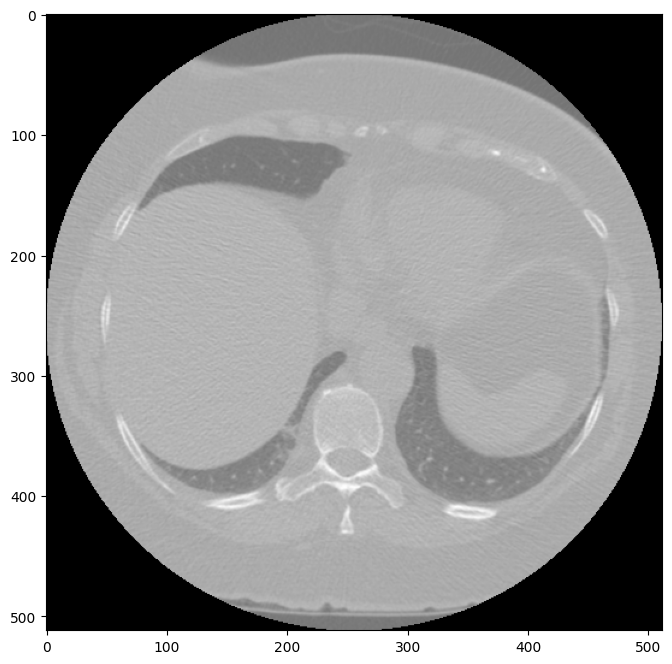

In [32]:
import matplotlib.pyplot as plt

# contour 그리기
coords = roi["coords"]

xs = [p[0] for p in coords]
ys = [p[1] for p in coords]

plt.figure(figsize=(8,8))

plt.imshow(image, cmap="gray")

plt.plot(xs, ys)

plt.show()

# z-position matching
ROI가 표시된 정확한 CT slice 찾기

In [33]:
# 현재 ROI z 확인
first_nodule = nodules[0]

roi = first_nodule["roi_list"][0]

print(roi["z"])

-26.5


In [35]:
# slice 폴더 경로 추출
dicom_dir = os.path.dirname(dcm_path)

print(dicom_dir)

/home/hdo/lidc_project/data/lidc-idri/manifest-1600709154662/LIDC-IDRI/LIDC-IDRI-0953/01-01-2000-NA-NA-60648/30291.000000-NA-84296


In [36]:
# 모든 slice z값 읽기
import glob

dcm_files = glob.glob(os.path.join(dicom_dir, "*.dcm"))

print("slice count:", len(dcm_files))

slice count: 372


In [39]:
# z 값 수집
slice_info = []

for path in dcm_files:

    dcm = pydicom.dcmread(path)

    z = float(dcm.ImagePositionPatient[2])

    slice_info.append((path, z))

print(slice_info[:5])

[('/home/hdo/lidc_project/data/lidc-idri/manifest-1600709154662/LIDC-IDRI/LIDC-IDRI-0953/01-01-2000-NA-NA-60648/30291.000000-NA-84296/1-329.dcm', -184.584991), ('/home/hdo/lidc_project/data/lidc-idri/manifest-1600709154662/LIDC-IDRI/LIDC-IDRI-0953/01-01-2000-NA-NA-60648/30291.000000-NA-84296/1-224.dcm', -118.959999), ('/home/hdo/lidc_project/data/lidc-idri/manifest-1600709154662/LIDC-IDRI/LIDC-IDRI-0953/01-01-2000-NA-NA-60648/30291.000000-NA-84296/1-270.dcm', -147.709991), ('/home/hdo/lidc_project/data/lidc-idri/manifest-1600709154662/LIDC-IDRI/LIDC-IDRI-0953/01-01-2000-NA-NA-60648/30291.000000-NA-84296/1-358.dcm', -202.709991), ('/home/hdo/lidc_project/data/lidc-idri/manifest-1600709154662/LIDC-IDRI/LIDC-IDRI-0953/01-01-2000-NA-NA-60648/30291.000000-NA-84296/1-161.dcm', -79.584999)]


In [41]:
# ROI z와 가장 가까운 slice 찾기
roi_z = float(roi["z"])

best_path = None
best_diff = 999999

for path, z in slice_info:

    diff = abs(z - roi_z)

    if diff < best_diff:

        best_diff = diff
        best_path = path

print("ROI z:", roi_z)
print("matched slice:", best_path)
print("difference:", best_diff)

ROI z: -26.5
matched slice: /home/hdo/lidc_project/data/lidc-idri/manifest-1600709154662/LIDC-IDRI/LIDC-IDRI-0953/01-01-2000-NA-NA-60648/30291.000000-NA-84296/1-076.dcm
difference: 0.040001000000000175
